# Cluster the food description embeddings
k-means is the standard; we'll start there.

In [1]:
!pip install kmeans-pytorch

In [2]:
# used G4 high RAM runtime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from kmeans_pytorch import kmeans

np.random.seed(222)
torch.manual_seed(222)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# link drive
from google.colab import drive
drive.mount('/content/drive')
share_path = "/content/drive/MyDrive/Colab_Notebooks/deeplearning2026"
import os
print(os.listdir(share_path))

Mounted at /content/drive
['documentation', 'notebooks', 'data', 'NLP-Arch.gdoc', 'Siavash']


In [5]:
# load data
data_path = share_path + "/data/"
df = pd.read_parquet(data_path + 'FDCwithTransformerEmbeddings.parquet.gzip')


## normalizing the embeddings is not necessary

In [6]:
X = np.vstack(df["embeddings"])
X

array([[-0.03410124,  0.02429589,  0.0010381 , ..., -0.04514918,
         0.00029233, -0.00648352],
       [-0.038947  , -0.04331378, -0.05184707, ..., -0.0789421 ,
         0.05405487,  0.07404439],
       [-0.02132339, -0.0637247 ,  0.02597385, ..., -0.00224153,
         0.02706381,  0.08679287],
       ...,
       [-0.01193981,  0.02561117, -0.0344268 , ..., -0.02338966,
         0.02926506, -0.00666313],
       [-0.06503326, -0.06791069, -0.07530647, ...,  0.02971989,
         0.02495179,  0.03971212],
       [-0.05889232, -0.03345546,  0.06011058, ..., -0.08681178,
         0.03373813, -0.08057716]], dtype=float32)

In [7]:
X = torch.from_numpy(X).float().to(device)
X

tensor([[-0.0341,  0.0243,  0.0010,  ..., -0.0451,  0.0003, -0.0065],
        [-0.0389, -0.0433, -0.0518,  ..., -0.0789,  0.0541,  0.0740],
        [-0.0213, -0.0637,  0.0260,  ..., -0.0022,  0.0271,  0.0868],
        ...,
        [-0.0119,  0.0256, -0.0344,  ..., -0.0234,  0.0293, -0.0067],
        [-0.0650, -0.0679, -0.0753,  ...,  0.0297,  0.0250,  0.0397],
        [-0.0589, -0.0335,  0.0601,  ..., -0.0868,  0.0337, -0.0806]],
       device='cuda:0')

In [8]:
k_range = range(15,31,3)

## k-Means clustering

In [9]:
# define functions using torch-based kmeans assessments

def compute_inertia(X, labels, centroids):
    assigned_centroids = centroids[labels]
    return torch.sum((X - assigned_centroids) ** 2).item()


def silhouette_sample_torch(X, labels, sample_size=5000):

    device = X.device
    N = X.shape[0]

    idx = torch.randperm(N, device=device)[:sample_size]

    Xs = X[idx]
    labels_s = labels[idx]

    dist = torch.cdist(Xs, Xs)

    unique_labels = labels_s.unique()

    silhouettes = []

    for i in range(sample_size):

        same_cluster = labels_s == labels_s[i]
        other_cluster_mask = labels_s != labels_s[i]

        a = dist[i][same_cluster].mean()

        b = torch.tensor(torch.inf, device=device)
        for lab in unique_labels:
            if lab == labels_s[i]:
                continue

            mask = labels_s == lab
            b = torch.minimum(b, torch.tensor(torch.mean(dist[i][mask]),
                                                  device=device))

        silhouettes.append((b - a) / torch.tensor(torch.maximum(a, b),
                                                  device=device))

    return torch.mean(torch.stack(silhouettes)).item()


def gap_statistic_torch(X, kmeans_func, k, sample_size=10000, B=5):

    device = X.device

    idx = torch.randperm(X.shape[0], device=device)[:sample_size]
    Xs = X[idx].to(device)

    labels, centroids = kmeans_func(Xs, k, device=device)

    labels = labels.to(device)

    centroids = centroids.to(device)

    Wk = torch.sum((Xs - centroids[labels]) ** 2)

    ref_disps = []

    mins = Xs.min(dim=0).values
    maxs = Xs.max(dim=0).values

    for _ in range(B):

        rand = torch.rand_like(Xs)
        X_ref = rand * (maxs - mins) + mins

        X_ref = torch.tensor(X_ref).to(device)

        labels_r, centroids_r = kmeans_func(X_ref, k, device=device)

        labels_r = labels_r.to(device)

        centroids_r = centroids_r.to(device)

        Wk_ref = torch.sum((X_ref - centroids_r[labels_r]) ** 2)

        ref_disps.append(torch.log(Wk_ref))

    gap = torch.mean(torch.stack(ref_disps)) - torch.log(Wk)

    return gap.item()

## Cluster!
Takes 10 minutes

In [10]:
results = []

for k in tqdm(k_range):

    labels, centroids = kmeans(X, k, device=device)

    df = pd.concat([df,
                    pd.Series(labels,
                              name = f'k{k}',
                              index = df.index)],
                   axis = 1)

    labels = labels.to(device)

    centroids = centroids.to(device)

    inertia = compute_inertia(X, labels, centroids)

    sil = silhouette_sample_torch(X, labels, sample_size = 10000)

    gap = gap_statistic_torch(X, kmeans, k=k)

    results.append((k, inertia, sil, gap))


  0%|          | 0/6 [00:00<?, ?it/s]

running k-means on cuda..



[running kmeans]: 0it [00:00, ?it/s]
[running kmeans]: 0it [00:01, ?it/s, center_shift=103.890305, iteration=1, tol=0.000100]
[running kmeans]: 1it [00:01,  1.39s/it, center_shift=103.890305, iteration=1, tol=0.000100]
[running kmeans]: 1it [00:02,  1.39s/it, center_shift=2.084669, iteration=2, tol=0.000100]  
[running kmeans]: 2it [00:02,  1.24s/it, center_shift=2.084669, iteration=2, tol=0.000100]
[running kmeans]: 2it [00:03,  1.24s/it, center_shift=0.656423, iteration=3, tol=0.000100]
[running kmeans]: 3it [00:03,  1.20s/it, center_shift=0.656423, iteration=3, tol=0.000100]
[running kmeans]: 3it [00:04,  1.20s/it, center_shift=0.328727, iteration=4, tol=0.000100]
[running kmeans]: 4it [00:04,  1.17s/it, center_shift=0.328727, iteration=4, tol=0.000100]
[running kmeans]: 4it [00:05,  1.17s/it, center_shift=0.198826, iteration=5, tol=0.000100]
[running kmeans]: 5it [00:05,  1.17s/it, center_shift=0.198826, iteration=5, tol=0.000100]
[running kmeans]: 5it [00:07,  1.17s/it, center_sh

running k-means on cuda:0..



[running kmeans]: 0it [00:00, ?it/s]
[running kmeans]: 0it [00:00, ?it/s, center_shift=100.213699, iteration=1, tol=0.000100]
[running kmeans]: 1it [00:00, 18.47it/s, center_shift=2.446144, iteration=2, tol=0.000100]
[running kmeans]: 2it [00:00, 25.00it/s, center_shift=0.845700, iteration=3, tol=0.000100]
[running kmeans]: 3it [00:00, 28.30it/s, center_shift=0.289750, iteration=4, tol=0.000100]
[running kmeans]: 4it [00:00, 37.63it/s, center_shift=0.289750, iteration=4, tol=0.000100]
[running kmeans]: 4it [00:00, 37.63it/s, center_shift=0.124208, iteration=5, tol=0.000100]
[running kmeans]: 5it [00:00, 37.63it/s, center_shift=0.082213, iteration=6, tol=0.000100]
[running kmeans]: 6it [00:00, 37.63it/s, center_shift=0.054205, iteration=7, tol=0.000100]
[running kmeans]: 7it [00:00, 37.63it/s, center_shift=0.035699, iteration=8, tol=0.000100]
[running kmeans]: 8it [00:00, 38.06it/s, center_shift=0.035699, iteration=8, tol=0.000100]
[running kmeans]: 8it [00:00, 38.06it/s, center_shift=

...


[running kmeans]: 0it [00:00, ?it/s]
[running kmeans]: 0it [00:00, ?it/s, center_shift=2451.956543, iteration=1, tol=0.000100]
[running kmeans]: 1it [00:00,  9.48it/s, center_shift=7.272956, iteration=2, tol=0.000100]
[running kmeans]: 2it [00:00, 18.89it/s, center_shift=7.272956, iteration=2, tol=0.000100]
[running kmeans]: 2it [00:00, 18.89it/s, center_shift=3.360456, iteration=3, tol=0.000100]
[running kmeans]: 3it [00:00, 18.89it/s, center_shift=2.020526, iteration=4, tol=0.000100]
[running kmeans]: 4it [00:00, 18.95it/s, center_shift=2.020526, iteration=4, tol=0.000100]
[running kmeans]: 4it [00:00, 18.95it/s, center_shift=1.264632, iteration=5, tol=0.000100]
[running kmeans]: 5it [00:00, 18.95it/s, center_shift=0.755731, iteration=6, tol=0.000100]
[running kmeans]: 6it [00:00, 18.61it/s, center_shift=0.755731, iteration=6, tol=0.000100]
[running kmeans]: 6it [00:00, 18.61it/s, center_shift=0.610308, iteration=7, tol=0.000100]
[running kmeans]: 7it [00:00, 18.61it/s, center_shift

running k-means on cuda:0..



[running kmeans]: 0it [00:00, ?it/s]
[running kmeans]: 0it [00:00, ?it/s, center_shift=2484.588867, iteration=1, tol=0.000100]
[running kmeans]: 1it [00:00,  9.28it/s, center_shift=7.256556, iteration=2, tol=0.000100]
[running kmeans]: 2it [00:00, 18.50it/s, center_shift=7.256556, iteration=2, tol=0.000100]
[running kmeans]: 2it [00:00, 18.50it/s, center_shift=3.414503, iteration=3, tol=0.000100]
[running kmeans]: 3it [00:00, 18.50it/s, center_shift=2.057372, iteration=4, tol=0.000100]
[running kmeans]: 4it [00:00, 18.70it/s, center_shift=2.057372, iteration=4, tol=0.000100]
[running kmeans]: 4it [00:00, 18.70it/s, center_shift=1.196265, iteration=5, tol=0.000100]
[running kmeans]: 5it [00:00, 18.70it/s, center_shift=0.846740, iteration=6, tol=0.000100]
[running kmeans]: 6it [00:00, 18.43it/s, center_shift=0.846740, iteration=6, tol=0.000100]
[running kmeans]: 6it [00:00, 18.43it/s, center_shift=0.610938, iteration=7, tol=0.000100]
[running kmeans]: 7it [00:00, 18.43it/s, center_shift

running k-means on cuda:0..



[running kmeans]: 0it [00:00, ?it/s]
[running kmeans]: 0it [00:00, ?it/s, center_shift=2474.965332, iteration=1, tol=0.000100]
[running kmeans]: 1it [00:00,  8.29it/s, center_shift=7.436177, iteration=2, tol=0.000100]
[running kmeans]: 2it [00:00, 16.53it/s, center_shift=7.436177, iteration=2, tol=0.000100]
[running kmeans]: 2it [00:00, 16.53it/s, center_shift=3.580357, iteration=3, tol=0.000100]
[running kmeans]: 3it [00:00, 16.53it/s, center_shift=2.101303, iteration=4, tol=0.000100]
[running kmeans]: 4it [00:00, 16.37it/s, center_shift=2.101303, iteration=4, tol=0.000100]
[running kmeans]: 4it [00:00, 16.37it/s, center_shift=1.433205, iteration=5, tol=0.000100]
[running kmeans]: 5it [00:00, 16.37it/s, center_shift=1.019230, iteration=6, tol=0.000100]
[running kmeans]: 6it [00:00, 16.49it/s, center_shift=1.019230, iteration=6, tol=0.000100]
[running kmeans]: 6it [00:00, 16.49it/s, center_shift=0.716768, iteration=7, tol=0.000100]
[running kmeans]: 7it [00:00, 16.49it/s, center_shift

In [11]:
ks = [r[0] for r in results]
inertias = [r[1] for r in results]
silhouettes = [r[2] for r in results]
gaps = [r[3] for r in results]

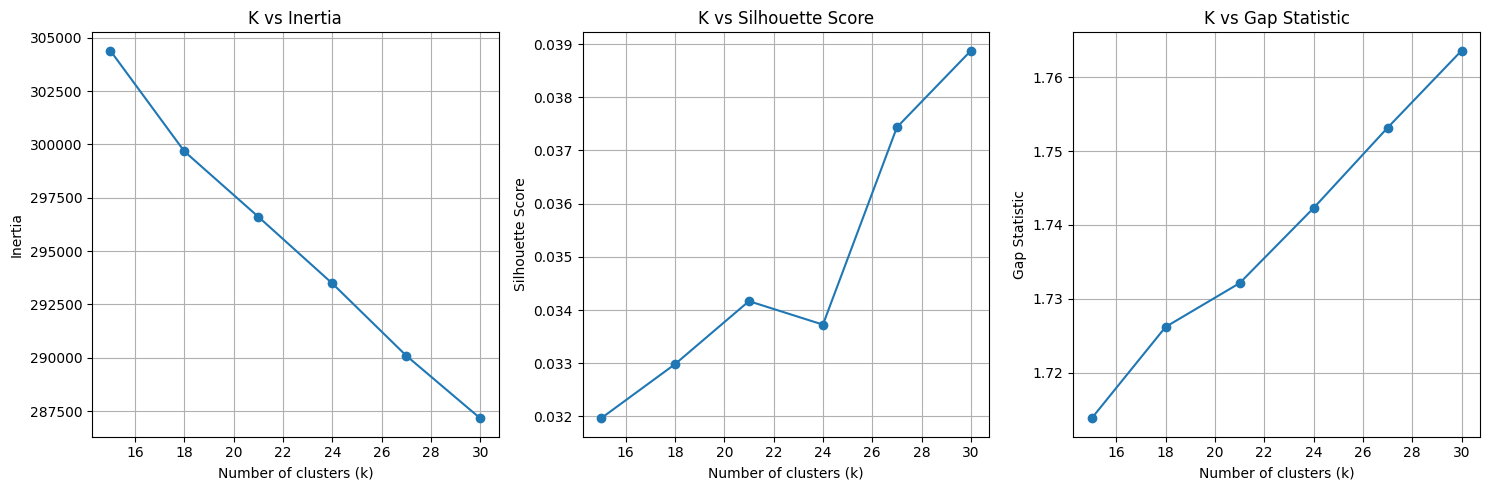

In [12]:
plt.figure(figsize=(15,5))

# Inertia
plt.subplot(1,3,1)
plt.plot(ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K vs Inertia")
plt.grid(True)

# Silhouette
plt.subplot(1,3,2)
plt.plot(ks, silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K vs Silhouette Score")
plt.grid(True)

# Gap Statistic
plt.subplot(1,3,3)
plt.plot(ks, gaps, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Gap Statistic")
plt.title("K vs Gap Statistic")
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
df.to_parquet(data_path + 'FDCkmeansclustered.parquet.gzip', compression='gzip')